<a href="https://colab.research.google.com/github/stutichaurasia238/ROV-MODEL-23/blob/main/FLOTEX_FINAL_PROJECT_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow ultralytics


In [ ]:


from roboflow import Roboflow
rf = Roboflow(api_key="RYBpNhvZVXlBvoYQZ0Yi")
project = rf.workspace("vanshika-yadav-tqytz").project("1amd10")
version = project.version(2)
dataset = version.download("yolov11")



loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov11 in progress : 85.0%
Version export complete for yolov11 format



Extracting Dataset Version Zip to 1AMD10-2 in yolov11:: 100%|██████████| 11168/11168 [00:01<00:00, 6248.85it/s]


In [ ]:
!nvidia-smi

Thu Apr 17 10:19:35 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.6/112.6 GB disk)


In [ ]:

from roboflow import Roboflow
rf = Roboflow(api_key="RYBpNhvZVXlBvoYQZ0Yi")
project = rf.workspace("vanshika-yadav-tqytz").project("1amd10")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=10 imgsz=640 plots=True

/content
100% 18.4M/18.4M [00:00<00:00, 208MB/s]
New https://pypi.org/project/ultralytics/8.3.109 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/1AMD10-2/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retin

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    results.png
confusion_matrix_normalized.png			    train_batch0.jpg
confusion_matrix.png				    train_batch1.jpg
events.out.tfevents.1744885270.09928baa7d36.5693.0  train_batch2.jpg
F1_curve.png					    val_batch0_labels.jpg
labels_correlogram.jpg				    val_batch0_pred.jpg
labels.jpg					    val_batch1_labels.jpg
P_curve.png					    val_batch1_pred.jpg
PR_curve.png					    val_batch2_labels.jpg
R_curve.png					    val_batch2_pred.jpg
results.csv					    weights


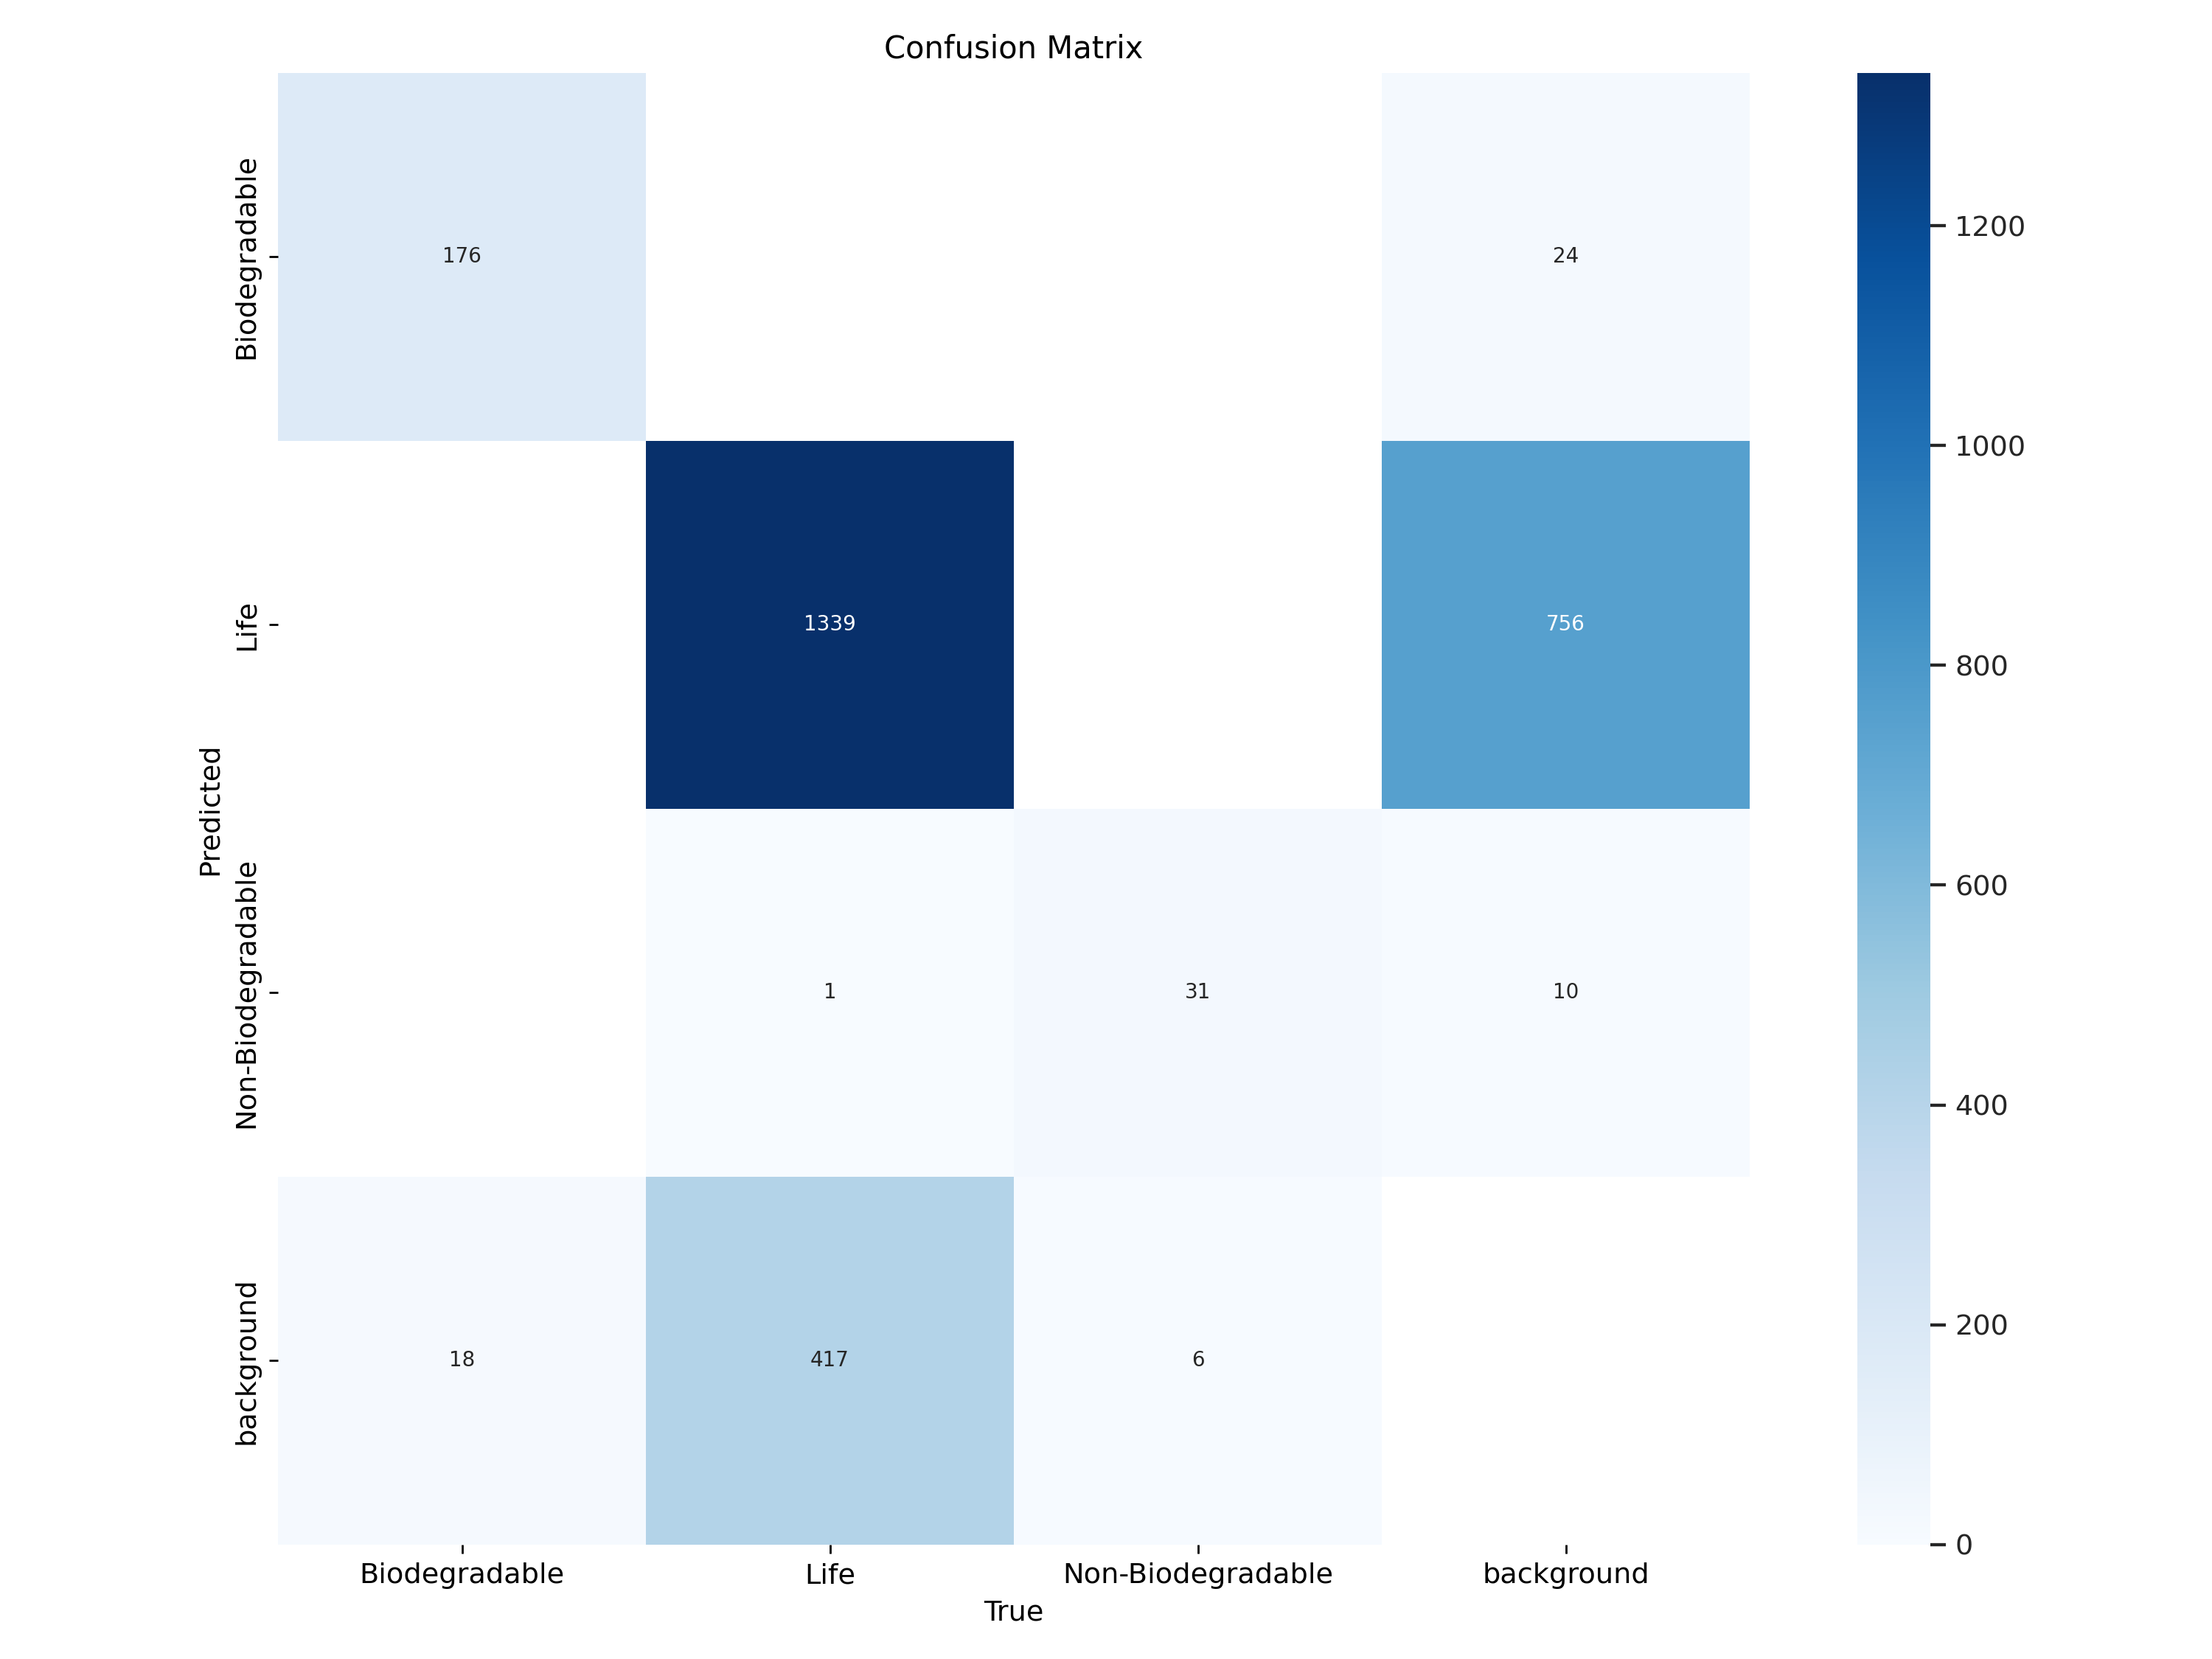

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

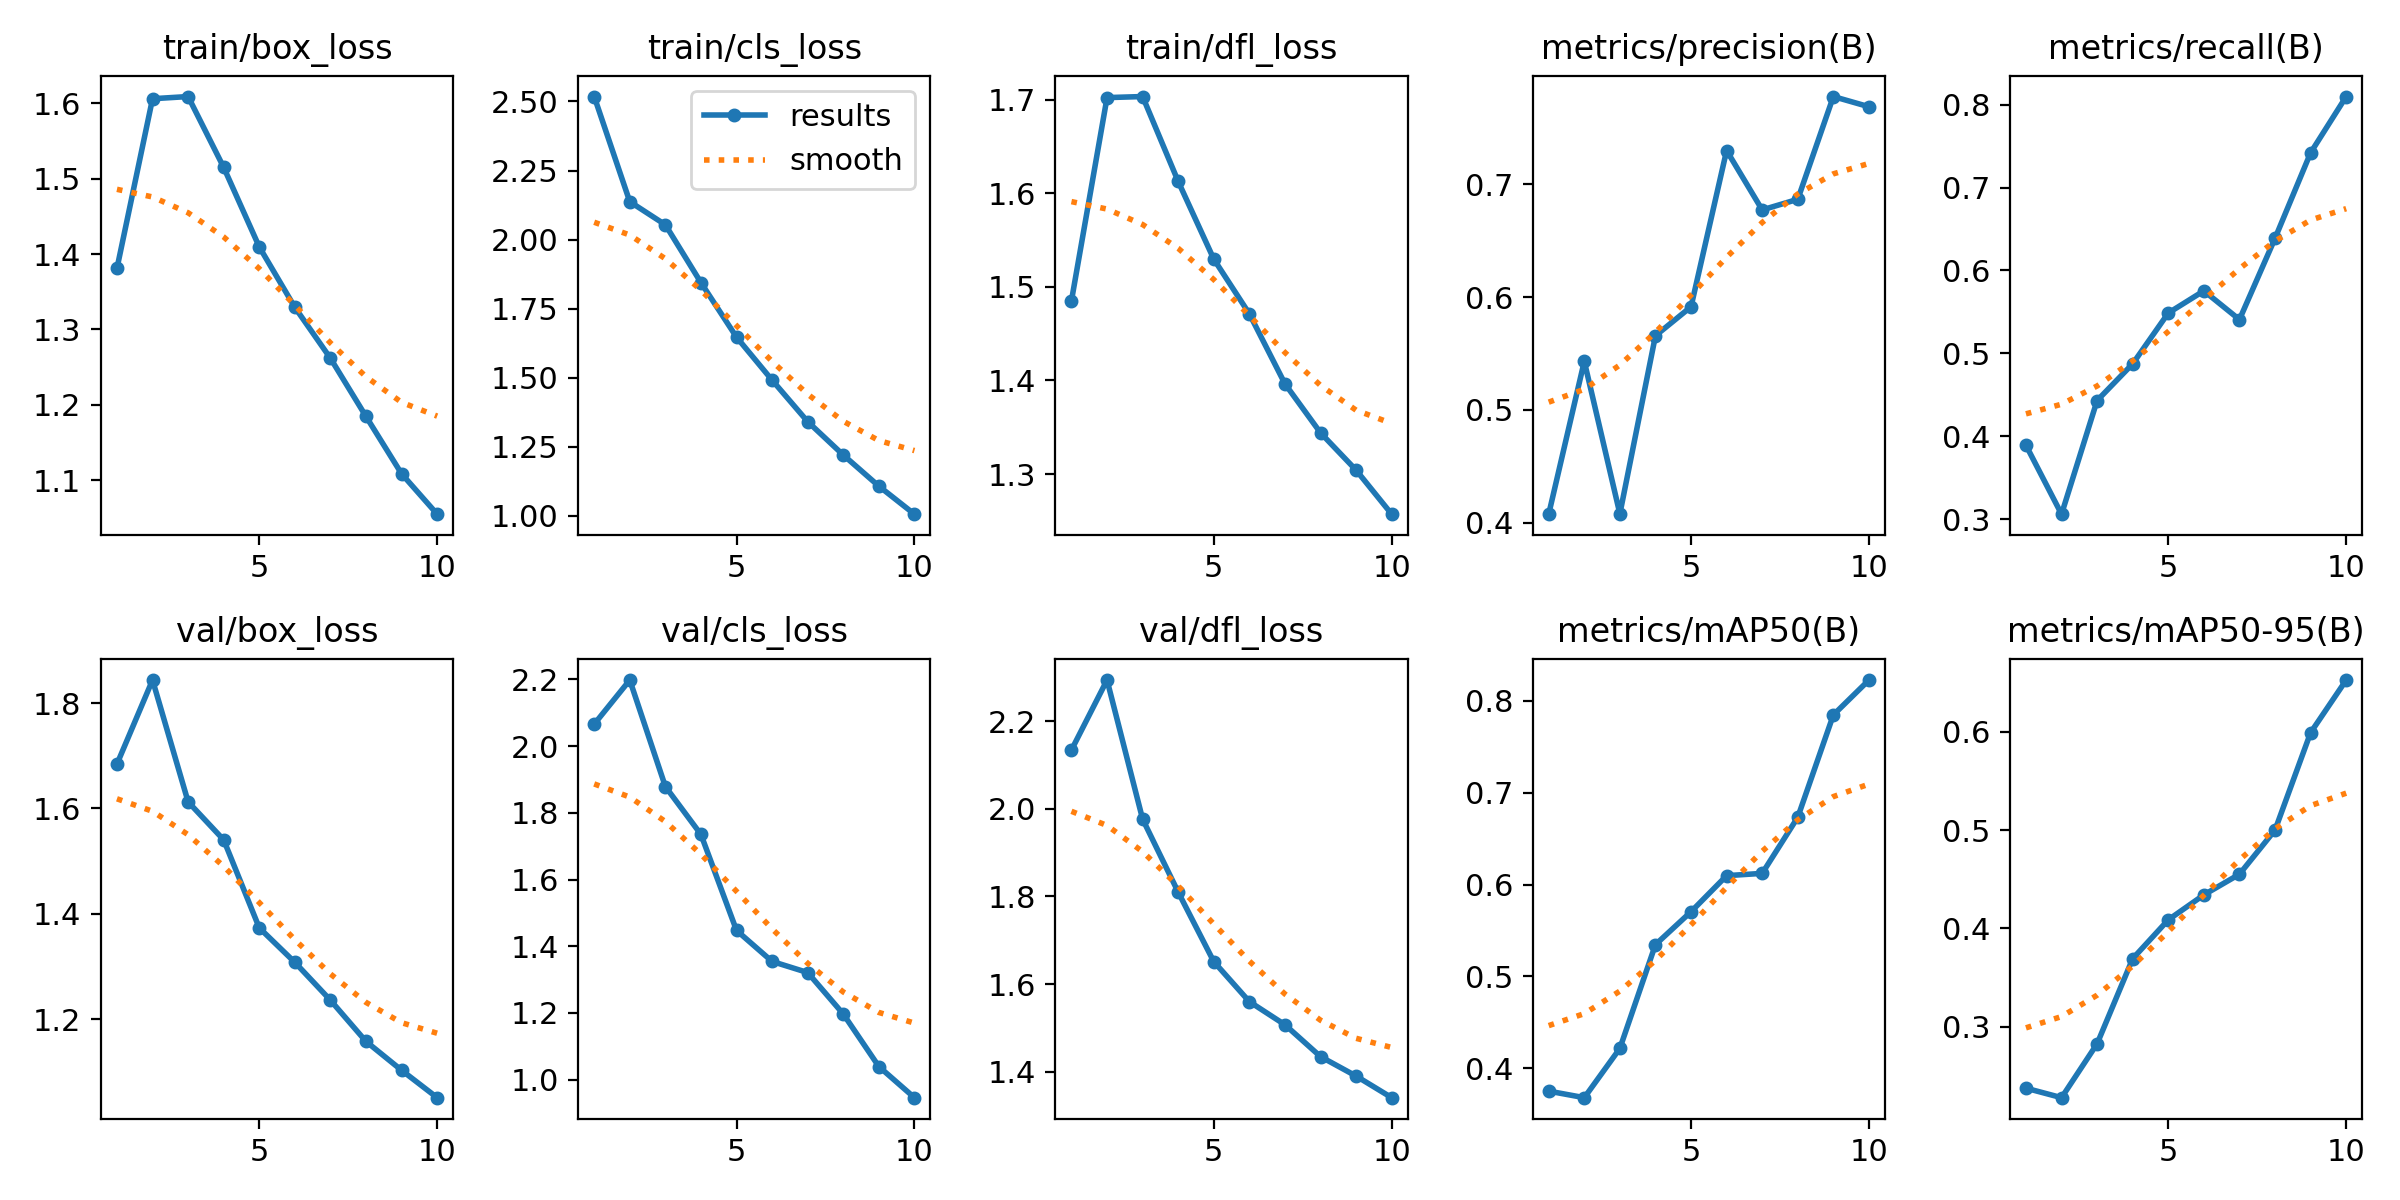

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

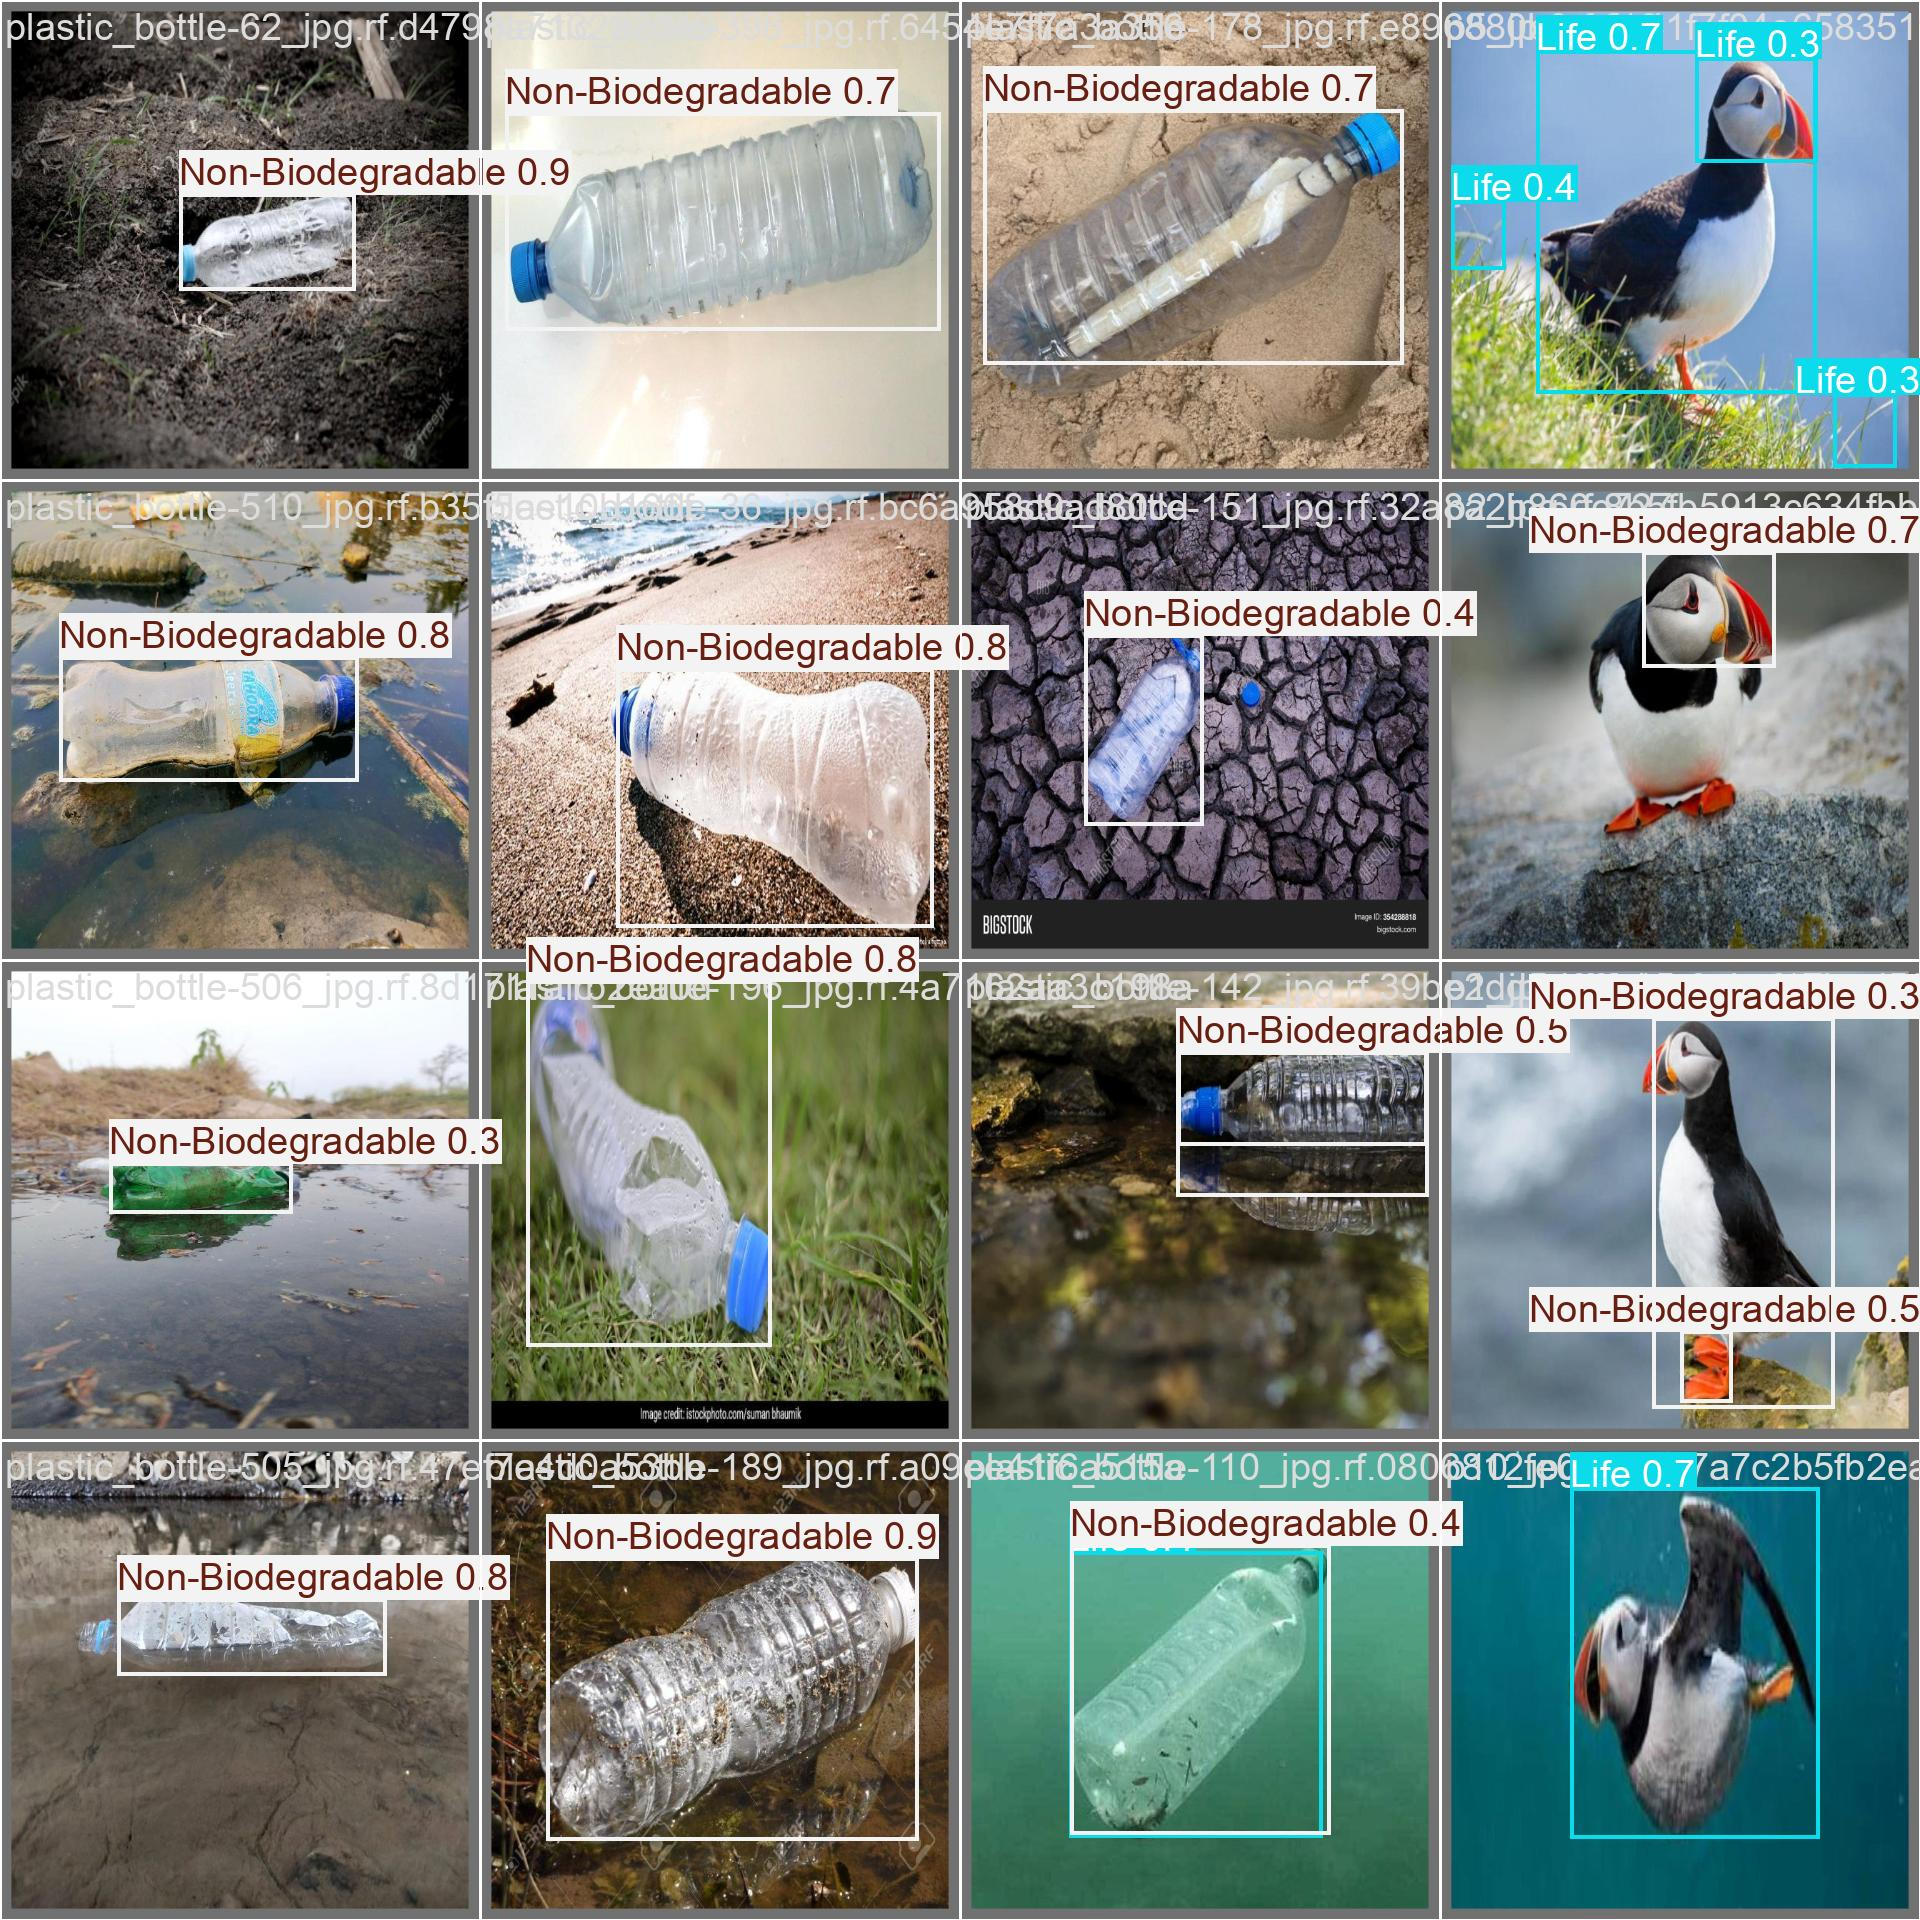

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/1AMD10-2/valid/labels.cache... 680 images, 10 backgrounds, 0 corrupt: 100% 680/680 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 194, len(boxes) = 1988. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 43/43 [00:09<00:00,  4.35it/s]
                   all        680       1988      0.767       0.81      0.822      0.652
         Biodegradable        164        194      0.906      0.895      0.929      0.819
                  Life        475       1757      0.676      0.725      0.744      0.454
     Non-Biodegradable         31         37 

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs

image 1/543 /content/1AMD10-2/test/images/00000021_jpg.rf.b88ed34f1acd8413df0331c87ee1205a.jpg: 640x640 2 Non-Biodegradables, 15.6ms
image 2/543 /content/1AMD10-2/test/images/000008_jpg.rf.df502f0d37475401dc3dd04462165d0a.jpg: 640x640 (no detections), 15.6ms
image 3/543 /content/1AMD10-2/test/images/000010_jpg.rf.c931e2207e23fe74e2191beba2149cc2.jpg: 640x640 1 Non-Biodegradable, 15.5ms
image 4/543 /content/1AMD10-2/test/images/000012_jpg.rf.4f750c82ed30b4446aab52b23cd2ab68.jpg: 640x640 2 Non-Biodegradables, 15.5ms
image 5/543 /content/1AMD10-2/test/images/000015_jpg.rf.a647052490270bf6b36f2149ee1708ec.jpg: 640x640 (no detections), 15.5ms
image 6/543 /content/1AMD10-2/test/images/000022_jpg.rf.bc8186e91c8c17cd712b14622a7bbd35.jpg: 640x640 3 Non-Biodegradables, 15.5ms
image 7/543 /content/1AMD10-2/test/images/000023_jpg.rf.

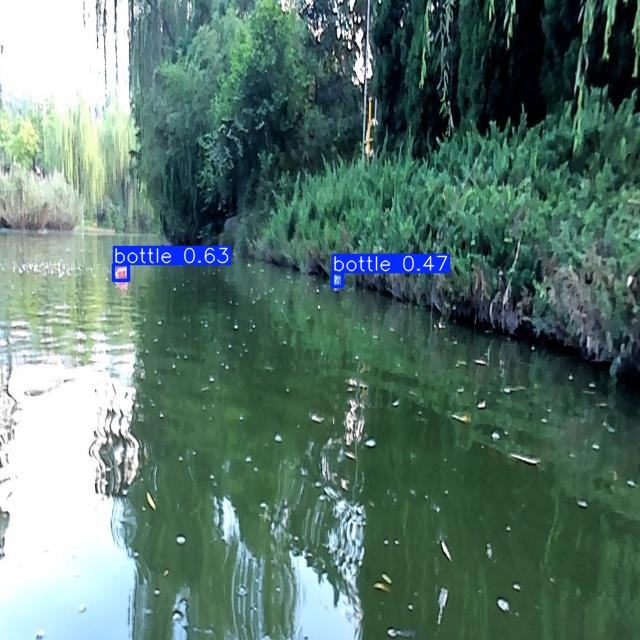

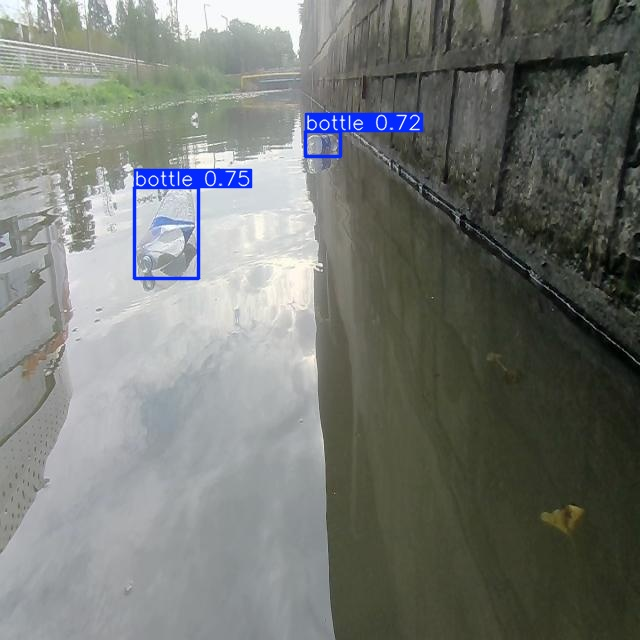

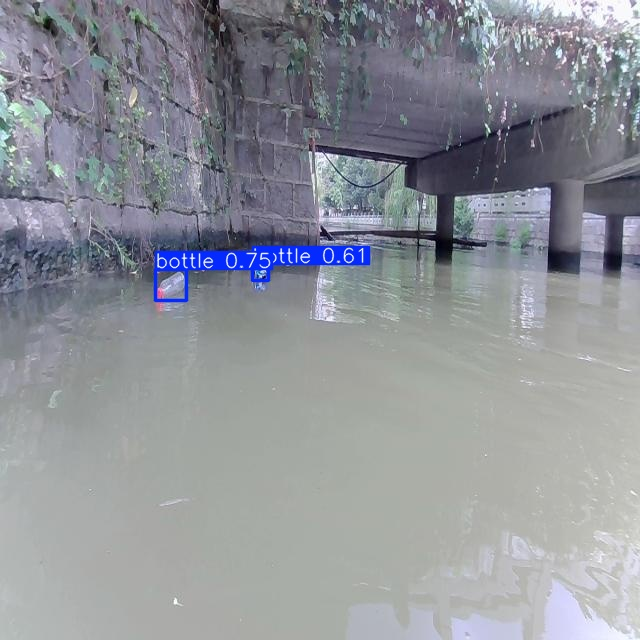

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
	display(IPyImage(filename=img, width=600))
	print("\n")